# ***Simple Chihuahua vs. Muffin image recognition test using numerical method functions***

Data collecting and cleaning process
in this projects, two images datasets have been used 1) training images datset and 2) CAPTCHA test images dataset:

Images dataset from Kaggle for training: https://www.kaggle.com/datasets/samuelcortinhas/muffin-vs-chihuahua-image-classification/data

Image dataset from Kaggle fro CAPTCHA test: https://www.kaggle.com/datasets/returnofsputnik/chihuahua-or-muffin?select=muffin-8.jpeg



In [49]:
# import images
from google.colab import drive
drive.mount('/content/drive')


training_chihuahua = "/content/drive/MyDrive/training/chihuahua"
training_muffin = "/content/drive/MyDrive/training/muffin"

captcha_chihuahua = "/content/drive/MyDrive/captcha/chihuahua"
captcha_muffin = "/content/drive/MyDrive/captcha/muffin"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[training_images_for_chihuahua](https://github.com/kaythep003/ICCS205_project/blob/main/Screenshot%202025-12-01%20040023.png)

[training_images_for_muffin](https://github.com/kaythep003/ICCS205_project/blob/main/Screenshot%202025-12-01%20040606.png)

**The main numerical methods that have been applied in this project are**

1. numerical derivative (finite differences)

and

2. linear regression(normal equation) for finding weights for a linear model to classify images

Numerical methods behind image preprocessing:

1) Converting image to greyscale, by using RGB color channels, reducing from 3 channels to 1 channel only. The purpose is to making the extraction process easier while still kepping the useful structure (ex. shapre, edges)

2) Image resizing using integer pixel coordinates. To ensure that images have equal sizes and same dimensions which will be required for applying machine learning

3) Converting integer pixel values into NumPy array

4) Normalize pixels to array of [0,1]. The pixel values typically range between 0 - 255, however it has to divided to prevent large gradients/ features which linear regression treats as more important to lower gradients. Moreover, it is easier to apply the scale when computing the upcoming linear combinations.

In [51]:
# first function for preprocessing images:
# 1) normal greyscale
# 2) resize for all images to have equal sizes
# 3) convert each image to vector of arrays
# 4) normalize images, adjusting pixel values for further analysis

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def preprocess_image(path, size=(64, 64), verbose=False):
    if verbose:
        print(f"--- Preprocessing for: {path} ---")

    # Open image and convert to grayscale
    img = Image.open(path).convert("L")
    if verbose:
        print("1. After converting to grayscale (PIL Image):")
        print(f"   - Mode: {img.mode}, Size: {img.size}")
        plt.imshow(img, cmap='gray')
        plt.title("Grayscale Image")
        plt.axis('off')
        plt.show()
        # Print a small sample of pixel values before converting to array
        print("   - Sample pixel values (top-left 5x5):")
        print(np.array(img)[:5, :5])

    # Resize the image
    img = img.resize(size)
    if verbose:
        print(f"\n2. After resizing to {size} (PIL Image):")
        print(f"   - Mode: {img.mode}, Size: {img.size}")
        plt.imshow(img, cmap='gray')
        plt.title(f"Resized Image ({size[0]}x{size[1]})")
        plt.axis('off')
        plt.show()
        print("   - Sample pixel values (top-left 5x5) after resize:")
        print(np.array(img)[:5, :5])

    # Convert to NumPy array with float32 dtype
    img_np = np.array(img, dtype=np.float32)
    if verbose:
        print("\n3. After converting to NumPy array (float32):")
        print(f"   - Shape: {img_np.shape}, Dtype: {img_np.dtype}")
        print(f"   - Min pixel value: {img_np.min()}, Max pixel value: {img_np.max()}")
        print("   - Sample pixel values (top-left 5x5):")
        print(img_np[:5, :5])

    # Normalize pixel values to [0, 1]
    img_np = img_np / 255.0
    if verbose:
        print("\n4. After normalizing pixel values (0-1):")
        print(f"   - Shape: {img_np.shape}, Dtype: {img_np.dtype}")
        print(f"   - Min pixel value: {img_np.min()}, Max pixel value: {img_np.max()}")
        print("   - Sample pixel values (top-left 5x5):")
        print(img_np[:5, :5])

    return img_np

--- Preprocessing for: /content/drive/MyDrive/captcha/chihuahua/chihuahua-1.jpg ---
1. After converting to grayscale (PIL Image):
   - Mode: L, Size: (171, 171)


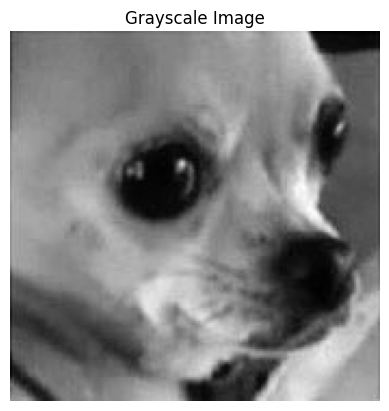

   - Sample pixel values (top-left 5x5):
[[52 77 78 74 77]
 [60 87 90 88 92]
 [58 85 89 88 93]
 [61 87 90 88 93]
 [63 87 89 87 93]]

2. After resizing to (64, 64) (PIL Image):
   - Mode: L, Size: (64, 64)


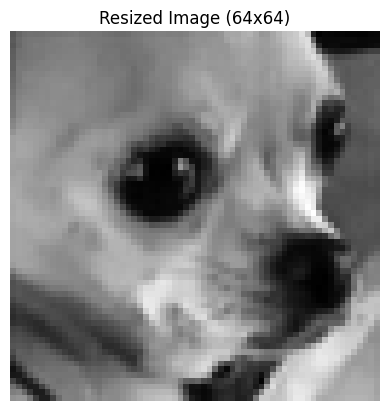

   - Sample pixel values (top-left 5x5) after resize:
[[ 75  87  93  96  95]
 [ 78  91  97 100 101]
 [ 75  90  97 101 104]
 [ 80  95  97 101 103]
 [ 81  96  98 101 103]]

3. After converting to NumPy array (float32):
   - Shape: (64, 64), Dtype: float32
   - Min pixel value: 4.0, Max pixel value: 211.0
   - Sample pixel values (top-left 5x5):
[[ 75.  87.  93.  96.  95.]
 [ 78.  91.  97. 100. 101.]
 [ 75.  90.  97. 101. 104.]
 [ 80.  95.  97. 101. 103.]
 [ 81.  96.  98. 101. 103.]]

4. After normalizing pixel values (0-1):
   - Shape: (64, 64), Dtype: float32
   - Min pixel value: 0.01568627543747425, Max pixel value: 0.8274509906768799
   - Sample pixel values (top-left 5x5):
[[0.29411766 0.34117648 0.3647059  0.3764706  0.37254903]
 [0.30588236 0.35686275 0.38039216 0.39215687 0.39607844]
 [0.29411766 0.3529412  0.38039216 0.39607844 0.40784314]
 [0.3137255  0.37254903 0.38039216 0.39607844 0.40392157]
 [0.31764707 0.3764706  0.38431373 0.39607844 0.40392157]]

Final preprocessed imag

In [52]:
# Showing example of preprocessing picture
import os

captcha_chihuahua_folder = "/content/drive/MyDrive/captcha/chihuahua"
chihuahua_image_path = os.path.join(captcha_chihuahua_folder, os.listdir(captcha_chihuahua_folder)[0])

preprocessed_chihuahua_img = preprocess_image(chihuahua_image_path, verbose=True)

print("\nFinal preprocessed image (NumPy array, 0-1 normalized):")
print(preprocessed_chihuahua_img[:5, :5]) # Print a sample of the final array

Numerical methods used for feature extraction;

1) Mean intensity - overall brightness of the image, muffin images often in cases, have darker average intensity compared to Chihuahua image

2) Standard deviation for contrast - Chihuahua faces tend to have sharp edged from eyes and noses (higher variance) compared to muffin images which are smoother(lower variance).

3) Horizontal symmetry (compare changes of the image from left to right) - compared the left side of the image and the flipped right side of the image by the number of pixels to measure the symmetric of the image

Chihuahua faces are almost always symmetric, especially the eyes and the nose on their face, while muffins tend to be random and asymmetrical.

4) Vertical smoothness (compare changes of the image from top to bottom)  - compute the vertical brightness using finite differnces from numercal dervative to measure the sudden brightness changes from one pixel to another (especially the facial features on chihuahua faces which has larger gradient)

5) Texture intensity - find the finite diffences (combine changes between horizontal gradient and vertical gradient and then find the mean)

 Chihuahua images tend to higher gradient magnitudes which found in their fur compared to muffin images.

In [38]:
def extract_features(img, verbose=False):
    """
    Feature extraction using numerical methods.
    """

    # Mean intensity
    f_mean = np.mean(img)
    if verbose:
        print(f"  - Feature: Mean Intensity (f_mean) = {f_mean:.4f}")

    # Standard deviation (contrast)
    f_std = np.std(img)
    if verbose:
        print(f"  - Feature: Standard Deviation (f_std) = {f_std:.4f}")

    # Horizontal symmetry
    left = img[:, :img.shape[1]//2]
    right = img[:, img.shape[1]//2:]
    right_flipped = np.fliplr(right)
    min_width = min(left.shape[1], right_flipped.shape[1])
    f_sym = np.mean(np.abs(left[:, :min_width] - right_flipped[:, :min_width]))
    if verbose:
        print(f"  - Feature: Horizontal Symmetry (f_sym) = {f_sym:.4f}")

    # Vertical smoothness
    vertical_profile = np.mean(img, axis=1)
    v_grad = np.diff(vertical_profile)
    f_vert_smooth = np.mean(np.abs(v_grad))
    if verbose:
        print(f"  - Feature: Vertical Smoothness (f_vert_smooth) = {f_vert_smooth:.4f}")

    # Texture: gradient magnitude
    gx = np.diff(img, axis=1)
    gy = np.diff(img, axis=0)

    # Corrected gradient magnitude calculation for compatible shapes (H-1, W-1)
    grad_mag = np.sqrt(gx[:-1, :]**2 + gy[:, :-1]**2)
    f_texture = np.mean(grad_mag)
    if verbose:
        print(f"  - Feature: Texture (f_texture) = {f_texture:.4f}")

    return np.array([f_mean, f_std, f_sym, f_vert_smooth, f_texture])

There are certain methods including here for feature extraction.

Selected distinct features for chihuahua vs muffin for applying algorithms in this project:


1) chihuahua face has eyes and noses, clear symmetrical features
* eye pair are symmetry
* nose-eye triangle ratio
* proportional of chihuahua eyes in the image


2) Color and texture differences
* smoother gradients (chihuahua) vs higher gradients (muffins)
* RGB ratio: muffins tend to have lighter yellow and distinct black/ dark color for chocolate chips or other fillings compared to chihuahua that tends to have consistent warmer color throughout the body except the eyes and snout, the colosr contrast in chihuahua images are usually less than muffin images

3) edge orientation: structured and horizontal edges image (facial features for chihuahuas) compared to random edges image (muffins) detection





In [53]:
# Example value of feature extraction from the same previous image

print("\n--- Feature extraction with verbose output ---")
features = extract_features(preprocessed_chihuahua_img, verbose=True)

print("\nFinal extracted feature vector:")
print(features)



--- Feature extraction with verbose output ---
  - Feature: Mean Intensity (f_mean) = 0.4029
  - Feature: Standard Deviation (f_std) = 0.1688
  - Feature: Horizontal Symmetry (f_sym) = 0.2053
  - Feature: Vertical Smoothness (f_vert_smooth) = 0.0097
  - Feature: Texture (f_texture) = 0.0509

Final extracted feature vector:
[0.4029383  0.1687799  0.20534813 0.0097125  0.05091771]


In [54]:
# downloading the rest of the dataset

def load_dataset(base_dir):
    X = []
    y = []

    for cls, label in {"chihuahua":0, "muffin":1}.items():
        folder = os.path.join(base_dir, cls)
        for fname in os.listdir(folder):
            if fname.lower().endswith(("jpg","png","jpeg")):
                img = preprocess_image(os.path.join(folder, fname))
                feat = extract_features(img)
                X.append(feat)
                y.append(label)

    return np.array(X), np.array(y)


Training the dataset
* add_bias function is used for creating a matrix using np.ones() - adding bias term column and np.hstack() methods
* The whole pupose is to matrix corresponds to the linear regression model

* train_linear_regression function is used based on the Nomal Equation for linear regression



In [55]:
# apply linear regression classifier
# model: y = w0+ w1x1+ w2x2 + .... + wnxn
def add_bias(X):
    return np.hstack([np.ones((X.shape[0],1)), X])

def train_linear_regression(X, y):

    # Closed-form solution: w = (X^T X)^(-1) X^T y

    Xb = add_bias(X) # Producing Xb term by adding bias column to
    XtX = Xb.T @ Xb # transpose of Xb
    XtX_inv = np.linalg.inv(XtX) # compute the inverse of XtX
    w = XtX_inv @ Xb.T @ y # compute the weights w by matrix multiplication
    return w

def predict_linear_regression(X, w):

    # Returns 0 or 1 (binary output) according to the linear model

    Xb = add_bias(X)
    preds = Xb @ w # computes predicted value
    return (preds > 0.5).astype(int) # apply for threshold, ensure that result is giving either 0 or 1


Training accuracy: 0.7729918509895227
Model weights: [-0.54049366  0.45399424 -0.62868618  0.23243906  4.530356    8.80749169]


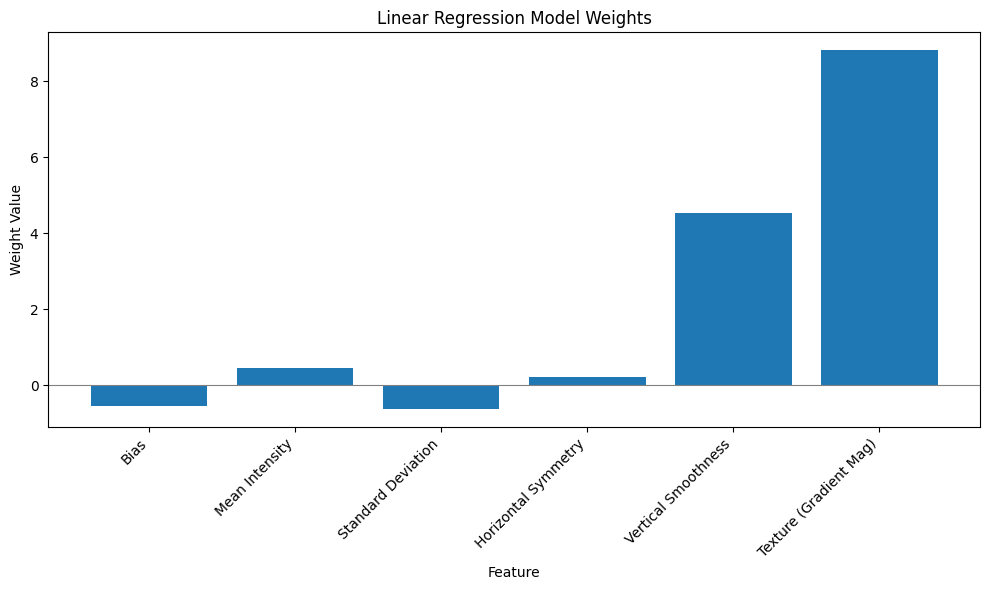

In [56]:
# apply the function and evaluate the accuracy

X, y = load_dataset("/content/drive/MyDrive/training")

w = train_linear_regression(X, y)

preds = predict_linear_regression(X, w)

# Checking accuracy
acc = np.mean(preds == y)
print("Training accuracy:", acc)


print("Model weights:", w)


# Visualization
# Feature names (matching the order of features extracted)
feature_names = ["Bias", "Mean Intensity", "Standard Deviation", "Horizontal Symmetry", "Vertical Smoothness", "Texture (Gradient Mag)"]

plt.figure(figsize=(10, 6))
plt.bar(feature_names, w)
plt.xlabel("Feature")
plt.ylabel("Weight Value")
plt.title("Linear Regression Model Weights")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, color='grey', linewidth=0.8) # Add a horizontal line at 0 for reference
plt.tight_layout()
plt.show()


The result from written classifier shows the 77% accurary of the training model which is expected since the model only captures the essential features from simple numerical methods and several feature extractions with no deep learning technique applied.

Moreover, according to the model weights visulaization, the texture gradient map is heavily relied on as a strong feature that influences the trained model and the prediction (fur pattern and sharp edges).

CAPCHAs evaluation

By the binary image classification problen from ptevious data training functions, the essence of this simple CAPTCHA is to distinguish which class the image belongs to using the trained linear model

[captcha_images_for_chihuahua](https://github.com/kaythep003/ICCS205_project/blob/main/Screenshot%202025-12-01%20040634.png)

[captcha_images_for_muffin](https://github.com/kaythep003/ICCS205_project/blob/main/Screenshot%202025-12-01%20040648.png)

In [57]:

def classify_image(path, w):
    img = preprocess_image(path)
    # converts the image to feature vectors
    feat = extract_features(img).reshape(1, -1)
    pred = predict_linear_regression(feat, w)[0]
    # from calcalated predicted value; 0 corresponding to chihuahua, 1 is corresponding to muffin
    return "chihuahua" if pred==0 else "muffin"

def run_captcha_test(folder, w):
    for fname in os.listdir(folder):
        if fname.lower().endswith(("jpg","png","jpeg")):
            label = classify_image(os.path.join(folder, fname), w)
            print(fname, "→", label)

run_captcha_test("/content/drive/MyDrive/captcha/chihuahua", w)
run_captcha_test("/content/drive/MyDrive/captcha/muffin", w)



chihuahua-1.jpg → chihuahua
chihuahua-2.jpg → chihuahua
chihuahua-3.jpg → chihuahua
chihuahua-4.jpg → chihuahua
chihuahua-5.jpg → chihuahua
chihuahua-6.jpg → chihuahua
chihuahua-7.jpg → chihuahua
chihuahua-8.jpg → chihuahua
muffin-1.jpeg → muffin
muffin-2.jpeg → chihuahua
muffin-3.jpeg → chihuahua
muffin-4.jpeg → muffin
muffin-5.jpeg → chihuahua
muffin-6.jpeg → muffin
muffin-7.jpeg → muffin
muffin-8.jpeg → chihuahua


[captcha_images_for_chihuahua_check](https://github.com/kaythep003/ICCS205_project/blob/main/Chihuahua.jpg)

[captcha_images_for_muffin_check](https://github.com/kaythep003/ICCS205_project/blob/main/Muffin.jpg)

In [58]:
# Calculate the overall CAPTCHA accuracy

def evaluate_captcha(ch_folder, muf_folder, w):
    results = []
    labels = []
    preds = []

    # Chihuahua CAPTCHA
    for fname in os.listdir(ch_folder):
        if fname.lower().endswith(("jpg","jpeg","png")):
            pred = classify_image(os.path.join(ch_folder, fname), w)
            preds.append(0 if pred=="chihuahua" else 1)
            labels.append(0)
            results.append((fname, pred))

    # Muffin CAPTCHA
    for fname in os.listdir(muf_folder):
        if fname.lower().endswith(("jpg","jpeg","png")):
            pred = classify_image(os.path.join(muf_folder, fname), w)
            preds.append(0 if pred=="chihuahua" else 1)
            labels.append(1)
            results.append((fname, pred))

    labels = np.array(labels)
    preds = np.array(preds)
    # comparing prediction values to the true labels
    acc = np.mean(labels == preds)
    # calculates the mean of prediction == true labels of all 16 test images

    print("CAPTCHA Accuracy:", acc)
    return labels, preds, results

labels, preds, results = evaluate_captcha(captcha_chihuahua, captcha_muffin, w)
# 12/16 = 0.75


CAPTCHA Accuracy: 0.75


From the CAPTCHA test, the classifer can classify all the chihuahua images correctly (8 out 8 images). However, for muffin CAPTCHA images, several images that resemble chihuahua faces got misclassified (correct only 4 out 8 images). This might result from confusion in several features such as resemblance in textures or shapes of muffins

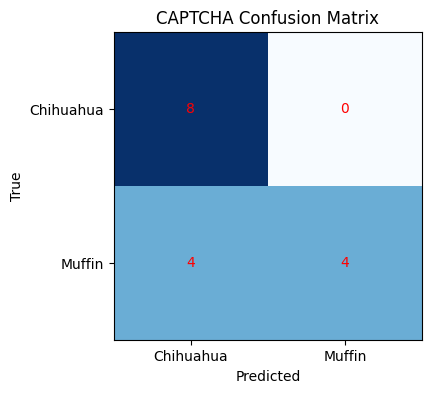

In [59]:
# confusion matrix for visualization

def plot_confusion_matrix(labels, preds):
    cm = np.zeros((2,2), dtype=int)
    for t, p in zip(labels, preds):
        cm[t, p] += 1

    plt.figure(figsize=(4,4))
    plt.imshow(cm, cmap='Blues')
    plt.xticks([0,1], ["Chihuahua","Muffin"])
    plt.yticks([0,1], ["Chihuahua","Muffin"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("CAPTCHA Confusion Matrix")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i,j], ha="center", va="center", color="red")

    plt.show()

plot_confusion_matrix(labels, preds)


***Discussion, limitations and conclusion:***

The classifier achieves 77% training accuracy and 75% CAPTCHA accuracy which is expected given the simplicity and amount of the numerical methods that have been used. The selected features for extraction has been too few and derived from basic numerical derivatives with some statistics. These features capture a single significant which is the texture or the gradient map of the picture. Since the functions for all the process(preprocessing, features extracting, applying model, CAPTCHA test) is entirely manual and relatively simple enough, the model does not capture the best essence in recognition the differences of two image classes comparing to apply more complex method such as deep learning technique

Certain improvements could be done by using more techniques and compare the accuracy such as gradient descent or logistic regression as a second feature extraction method and compare the results, or applying more well rounded techniques such as Taylor's expansion for denoising image and analyze further images behaviors.
